## Dataset Reading && Sampling frames

This notebook is completed by using Google colab, and the saved file is located in Google Drive.

If you would like to run this notebook in your local machinese,
You could simplyly change the "deepfake_dir" , "original_dir", and "save_dir" to your local file address.

In [1]:
# use for face location
!pip install mediapipe


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 21.2 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
import os
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from tqdm import tqdm

data_dir = Path("/content/sample_data")
# Get accss to the Google Drive to read the dataset
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
deepfake_dir = "/content/drive/MyDrive/sample_data/manipulated_sequences/Deepfakes/c23/videos"
original_dir = "/content/drive/MyDrive/sample_data/original_sequences/youtube/c23/videos"
save_dir = "/content/drive/MyDrive/Deepfake_Project_Data"
cross_data_real = "/content/drive/MyDrive/cross_dataset_real"
cross_data_fake = "/content/drive/MyDrive/cross_dataset_fake"
cross_data_save_dir= "/content/drive/MyDrive/Cross_dataset_Data"

num_frames = 16
target_size = (224, 224)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
if not os.path.exists(cross_data_save_dir):
    os.makedirs(cross_data_save_dir)


In [4]:
print(mp.__version__)


0.10.35


In [5]:
# init the mediapip object for face location, and using the exist model from mediapip documentation
# https://ai.google.dev/edge/mediapipe/solutions/vision/face_detector#blazeface_short-range
BaseOptions = mp.tasks.BaseOptions
FaceDetector = mp.tasks.vision.FaceDetector
FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions

options = FaceDetectorOptions(
    base_options=BaseOptions(model_asset_path="/content/drive/MyDrive/Model/blaze_face_short_range.tflite"),
    running_mode=mp.tasks.vision.RunningMode.IMAGE,
    min_detection_confidence=0.5
)
face_detector = FaceDetector.create_from_options(options)

## Frame Extraction, and Save into Google Drive

This two function is extrat frames from video, and save them into the google Drive, so we don't have to rerun the whole thing again and again. ( I highly suggest running the whole note book on google colab, otherwise, you may need to reset the save path into your local file path)

In [6]:
import cv2
# This function is for sampling and data cleaning, and processing(Fram sampling, face location,Crop and Normalizing,)
def process_video_to_faces(video_path, num_frames, target_size):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    # using Equidistant Sampling for the baseline .
    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    face_sequence = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue

        # BGR transfor to RGB, so mediapip are able to process
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

        results = face_detector.detect(mp_image)

        if results.detections:
            bbox = results.detections[0].bounding_box
            ih, iw, _ = frame.shape

            # adding a 3% margin to the egege, to see if there any deepfake cues.
            margin_w = int(bbox.width * 0.03)
            margin_h = int(bbox.height * 0.03)

            x = int(max(0, bbox.origin_x - margin_w // 2))
            y = int(max(0, bbox.origin_y - margin_h // 2))
            w = int(min(iw - x, bbox.width + margin_w))
            h = int(min(ih - y, bbox.height + margin_h))

            face_crop = frame_rgb[y:y+h, x:x+w]
            if face_crop.size > 0:
                # resize the frame to 224*224
                face_crop = cv2.resize(face_crop, target_size)
                # this is normalization
                face_sequence.append(face_crop.astype(np.float32) / 255.0)

    cap.release()

    # if the frames capture is less than 16, throws away
    return np.array(face_sequence) if len(face_sequence) == num_frames else None

In [ ]:
import gc
def run_batch_processing(source_dir, label_name, label_value, save_dir, batch_size=50):
    if not os.path.exists(source_dir):
        print(f"can't find  {source_dir}")
        return

    video_files = [f for f in os.listdir(source_dir) if f.endswith('.mp4')]
    current_data, current_labels = [], []
    batch_idx = 1

    print(f"handing {label_name} video，total: {len(video_files)}")

    ## iteralying each video and extrat num_frames for each video
    for i, filename in enumerate(tqdm(video_files)):
        video_path = os.path.join(source_dir, filename)
        faces = process_video_to_faces(video_path, num_frames, target_size)

        if faces is not None:
            current_data.append(faces)
            current_labels.append(label_value)

        # if we have enought bath, then save it into google drive
        if len(current_data) == batch_size or i == len(video_files) - 1:
            if len(current_data) > 0:
                np.save(f"{save_dir}/{label_name}_data_b{batch_idx}.npy", np.array(current_data))
                np.save(f"{save_dir}/{label_name}_label_b{batch_idx}.npy", np.array(current_labels))
                batch_idx += 1
                del current_data, current_labels
                gc.collect()
                current_data, current_labels = [], []

    # Save the file into google drive
    print(f"{label_name} video handle successfuly！file saved at: {save_dir}")

# label and data cleaning and preprocessing
# real video label as 0  deepfake video label as 1
run_batch_processing(original_dir, "real", 0, save_dir)
run_batch_processing(deepfake_dir, "fake",1 ,save_dir)

In [7]:
import glob

def load_processed_data(data_dir):
    # get all of the data from google drive to aviod rerunning the extract frames again and again.
    data_files = sorted(glob.glob(f"{data_dir}/*_data_b*.npy"))
    label_files = sorted(glob.glob(f"{data_dir}/*_label_b*.npy"))

    X = np.concatenate([np.load(f) for f in data_files])
    y = np.concatenate([np.load(f) for f in label_files])

    print(f"Data loading complete!")
    print(f"Total Features (X) shape: {X.shape}")
    print(f"Total Labels (y) shape: {y.shape}")
    return X, y

X, y = load_processed_data(save_dir)

Data loading complete!
Total Features (X) shape: (1227, 16, 224, 224, 3)
Total Labels (y) shape: (1227,)


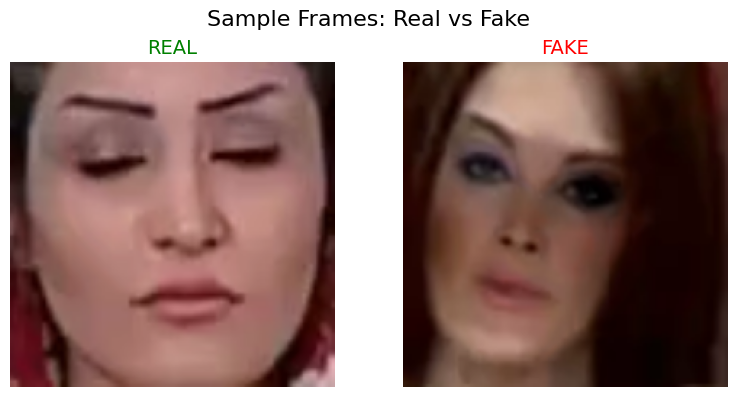

In [8]:
# This function is shows how the frames looks like after the data been crop, and process

import matplotlib.pyplot as plt

real_indices = np.where(y == 0)[0]
fake_indices = np.where(y == 1)[0]

real_idx = np.random.choice(real_indices)
fake_idx = np.random.choice(fake_indices)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(X[real_idx, 0])
axes[0].set_title("REAL", fontsize=14, color='green')
axes[0].axis('off')

axes[1].imshow(X[fake_idx, 0])
axes[1].set_title("FAKE", fontsize=14, color='red')
axes[1].axis('off')

plt.suptitle("Sample Frames: Real vs Fake", fontsize=16)
plt.tight_layout()
plt.show()

# Exploratory Data Analysis (EDA)

## Class Balance:

/tmp/ipykernel_896/1010460765.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette=['#3498db', '#e74c3c'])


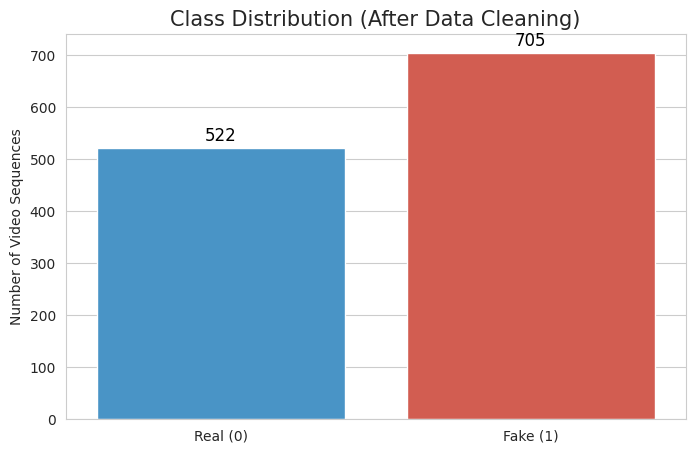

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

counts = pd.Series(y).value_counts().sort_index()
labels = ['Real (0)', 'Fake (1)']

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = sns.barplot(x=labels, y=counts.values, palette=['#3498db', '#e74c3c'])

# using histograms to shows the distribution after data cleaning
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title("Class Distribution (After Data Cleaning)", fontsize=15)
plt.ylabel("Number of Video Sequences")
plt.show()

## Univariate Analysis:

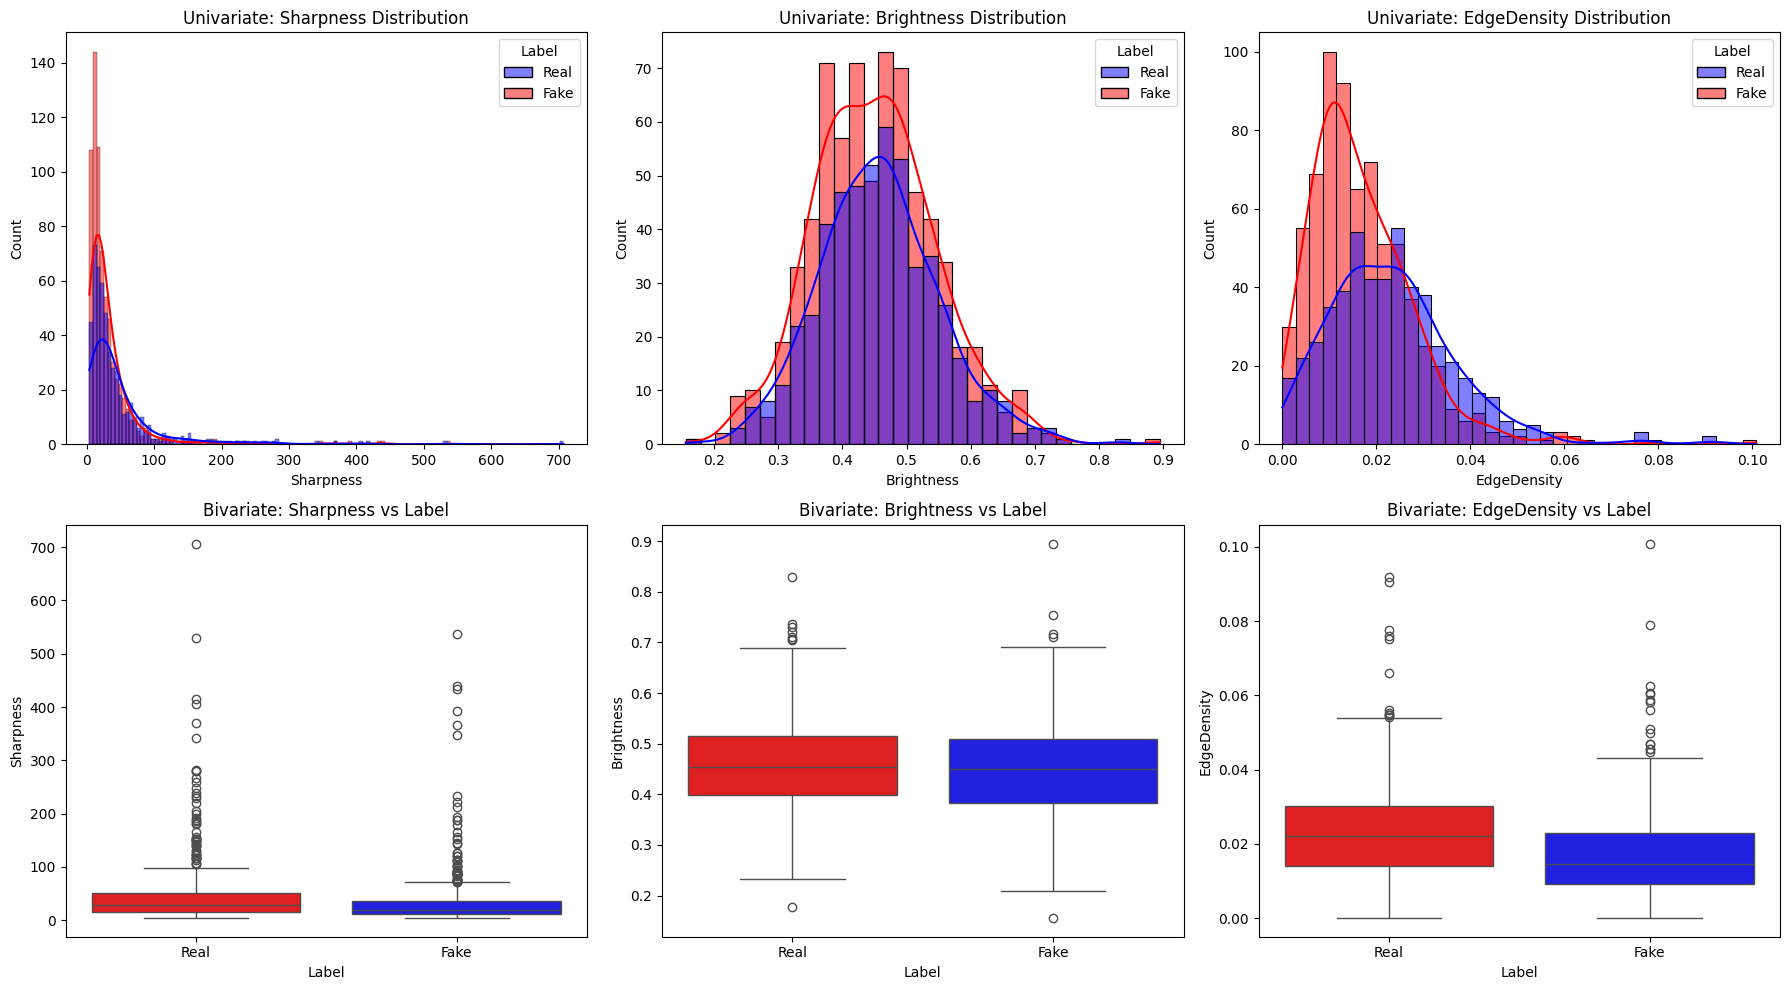

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sharpness_list = []
edge_density_list = []

for video in X:
    frame = video[0]
    gray = cv2.cvtColor((frame * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness_list.append(sharpness)

    edges = cv2.Canny(gray, 100, 200)
    density = np.sum(edges > 0) / edges.size
    edge_density_list.append(density)

mean_sharpness = np.array(sharpness_list)
edge_density = np.array(edge_density_list)
mean_brightness = X[:, 0].mean(axis=(1, 2, 3))

# make a dataframe for plotting
df_eda = pd.DataFrame({
    'Brightness':  mean_brightness,
    'Sharpness':   mean_sharpness,
    'EdgeDensity': edge_density,
    'Label': ['Real' if i == 0 else 'Fake' for i in y]
})

features = ['Sharpness', 'Brightness', 'EdgeDensity']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# build a plot that shows features to label (Univariate and Bivariate)
for col, feature in enumerate(features):
    sns.histplot(data=df_eda, x=feature, hue='Label', kde=True,
                 ax=axes[0, col], palette=['blue', 'red'], alpha=0.5,
                 hue_order=['Real', 'Fake'])
    axes[0, col].set_title(f'Univariate: {feature} Distribution')


for col, feature in enumerate(features):
    sns.boxplot(data=df_eda, x='Label', y=feature,
                ax=axes[1, col], palette=['blue', 'red'],
                order=['Real', 'Fake'], hue='Label', legend=False)
    axes[1, col].set_title(f'Bivariate: {feature} vs Label')

plt.tight_layout()
plt.show()


## Bivariate Analysis:

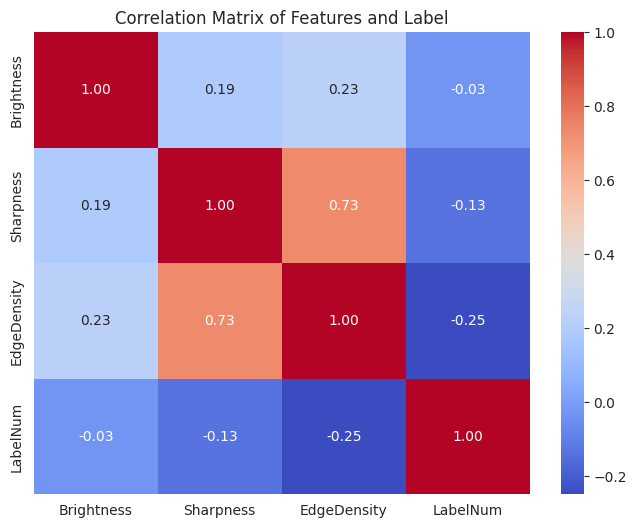

In [ ]:
# ---------- Correlation Matrix ----------
corr_df = df_eda[['Brightness', 'Sharpness', 'EdgeDensity']].copy()
corr_df['LabelNum'] = (df_eda['Label'] == 'Fake').astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features and Label')
plt.show()

# Model Setup And Tranning

## Dataset Loader

In [10]:
import random
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as F
class DeepfakeVideoDataset(Dataset):
    def __init__(self, X, y, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5), train=True):
      self.X = X
      self.y = y
      self.mean = torch.tensor(mean).view(1, 3, 1, 1)
      self.std = torch.tensor(std).view(1, 3, 1, 1)
      self.train = train
      self.color_jitter = T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)

    def __len__(self):
      return len(self.X)

    def jpeg_compress(self, frame_np, quality):
        # frame_np: float32 [0,1] HWC  →  compress →  float32 [0,1] HWC
        img_uint8 = (frame_np * 255).astype(np.uint8)
        encode_param = [cv2.IMWRITE_JPEG_QUALITY, quality]
        _, enc = cv2.imencode('.jpg', img_uint8, encode_param)
        decoded = cv2.imdecode(enc, cv2.IMREAD_COLOR)          # BGR
        decoded = cv2.cvtColor(decoded, cv2.COLOR_BGR2RGB)
        return decoded.astype(np.float32) / 255.0

    def apply_jpeg_compression(self, video):
      quality = random.choice([30, 40, 50, 60, 70, 85])
      frames = []

      for i in range(video.shape[0]):
          frame_np = video[i].permute(1, 2, 0).cpu().numpy()
          frame_np = self.jpeg_compress(frame_np, quality)
          frame_t = torch.tensor(frame_np, dtype=torch.float32).permute(2, 0, 1)
          frames.append(frame_t)

      return torch.stack(frames)

    def apply_resize_degradation(self, video):
        scale = random.choice([0.5, 0.6, 0.75])
        frames = []

        for i in range(video.shape[0]):
            h, w = video[i].shape[-2:]
            small_h = int(h * scale)
            small_w = int(w * scale)

            small = F.resize(video[i], [small_h, small_w])
            back = F.resize(small, [h, w])
            frames.append(back)

        return torch.stack(frames)

    def apply_gaussian_blur(self, video):
        kernel_size = random.choice([3, 5])
        sigma = random.uniform(0.1, 1.5)

        frames = []
        for i in range(video.shape[0]):
            f = F.gaussian_blur(video[i], kernel_size=[kernel_size, kernel_size], sigma=[sigma, sigma])
            frames.append(f)

        return torch.stack(frames)

    def __getitem__(self, idx):

      video = self.X[idx]   # (T, H, W, C)
      label = self.y[idx]

      # numpy -> torch
      video = torch.tensor(video, dtype=torch.float32).permute(0, 3, 1, 2).contiguous()

      # randomly do data argumentaion for training dataset, while training for reduce overfiting.

      if self.train:
          # greyscale the image with 0.2 probability
          if random.random() > 0.5:
              self.apply_jpeg_compression(video)

          # randomly rotatio to trainig data
          if random.random() > 0.5:
              angle = random.uniform(-10, 10)
              video = torch.stack([F.rotate(video[i], angle) for i in range(video.shape[0])])

          if random.random() < 0.3:
                video = self.apply_resize_degradation(video)

            # 3. Blur: simulate motion blur / camera blur
          if random.random() < 0.2:
                video = self.apply_gaussian_blur(video)

          if random.random() > 0.5:
              video = F.hflip(video)

          if random.random() > 0.5:
              params = T.ColorJitter.get_params(
                  self.color_jitter.brightness,
                  self.color_jitter.contrast,
                  self.color_jitter.saturation,
                  self.color_jitter.hue
              )
              _, brightness_factor, contrast_factor, saturation_factor, hue_factor = params

              frames = []
              for i in range(video.shape[0]):
                  f = video[i].clone()
                  f = F.adjust_brightness(f, brightness_factor)
                  f = F.adjust_contrast(f, contrast_factor)
                  f = F.adjust_saturation(f, saturation_factor)
                  f = F.adjust_hue(f, hue_factor)
                  frames.append(f)
              video = torch.stack(frames)

      # normalization
      video = (video - self.mean) / self.std
      return video, torch.tensor(label, dtype=torch.float32)

# Deepfake Detector with Dual-Channel Temporal Architecture




In [11]:
import torch
import torch.nn as nn
class TemporalAttentionPooling(nn.Module):
    def __init__(self, embed_dim, attn_dim=256, dropout=0.2):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(embed_dim, attn_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attn_dim, 1)
        )

    def forward(self, x):
        # x: (B, T, D)
        scores = self.attn(x)              # (B, T, 1)
        weights = torch.softmax(scores, dim=1)  # (B, T, 1)
        pooled = (x * weights).sum(dim=1)       # (B, D)
        return pooled, weights

In [12]:

# SRMLayer is a fixed convolutional filtering layer for my second channel.

class SRMLayer(nn.Module):
    def __init__(self):
        super().__init__()
        kernels = torch.tensor([
            [[[ 0,-1, 0],[-1, 4,-1],[ 0,-1, 0]]],
            [[[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]]],
            [[[ 1, 2, 1],[ 0, 0, 0],[-1,-2,-1]]],
        ], dtype=torch.float32)  # (3, 1, 3, 3)
        self.conv = nn.Conv2d(1, 3, 3, padding=1, bias=False)
        self.conv.weight = nn.Parameter(kernels, requires_grad=False)

    def forward(self, x):
        gray = x.mean(dim=1, keepdim=True)   # (N, 1, H, W)
        out  = self.conv(gray)               # (N, 3, H, W)
        return torch.tanh(out / 4.0)

In [13]:

from transformers import ViTModel
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


class DualChannelDeepfakeDetector(nn.Module):
    def __init__(self, model_name="google/vit-base-patch16-224", freeze_vit=True, dropout=0.3):
        super().__init__()
        self.vit = ViTModel.from_pretrained(model_name)
        self.embed_dim = self.vit.config.hidden_size  # 768
        if freeze_vit:
            for p in self.vit.parameters():
                p.requires_grad = False
            for p in self.vit.encoder.layer[-1].parameters():
                p.requires_grad = True

        self.temporal_pool_rgb = TemporalAttentionPooling(
            embed_dim=self.embed_dim, attn_dim=256, dropout=dropout
        )

        self.srm = SRMLayer()

        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.efficientnet = nn.Sequential(*list(backbone.children())[:-1])

        # frozen all layer first
        for p in self.efficientnet.parameters():
            p.requires_grad = False

        # unfreeze the last layer for learning SRM feature
        for p in self.efficientnet[-1].parameters():
            p.requires_grad = True

        self.freq_project = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.temporal_pool_freq = TemporalAttentionPooling(
            embed_dim=256, attn_dim=128, dropout=dropout
        )


        # feat1: 768, feat2: 256 → concat → 1024
        self.fusion = nn.Sequential(
            nn.Linear(768 + 256, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def encode_rgb(self, x):
        B, T, C, H, W = x.shape

        # flatten all of the frame with number of batch , and processe to ViT
        x_flat = x.view(B * T, C, H, W)

        # Extract CLS token from ViT output for each frame  (B*T, 768)
        cls = self.vit(pixel_values=x_flat).last_hidden_state[:, 0]

        # Restore temporal structure for temporal pooling layer:
        cls = cls.view(B, T, self.embed_dim)
        feat, attn_w = self.temporal_pool_rgb(cls)   # (B, 768)
        return feat, attn_w

    def encode_freq(self, x):
        """x: (B, T, C, H, W)"""
        B, T, C, H, W = x.shape
        # flatten all of the frame with number of batch , and processe to ViT

        x_flat = x.view(B * T, C, H, W)

        # Apply SRM filter / frequency enhancement on each frame with size (B*T, 3, H, W)
        srm_out = self.srm(x_flat)
        # Extract frame-level frequency features using EfficientNet with size (B*T, 1280, 1, 1)
        feat = self.efficientnet(srm_out)
        feat = self.freq_project(feat)
        # Restore temporal structure for temporal pooling layer:
        feat = feat.view(B, T, 256)
        feat, attn_w = self.temporal_pool_freq(feat)
        return feat, attn_w

    def forward(self, x):
        feat_rgb,  attn_rgb  = self.encode_rgb(x)
        feat_freq, attn_freq = self.encode_freq(x)

        # concated feature rgb and feature frequency( 768 + 256)
        concated  = torch.cat([feat_rgb, feat_freq], dim=-1)
        # fused the concated feature
        fused  = self.fusion(concated)
        # model classified the concated feature
        logits = self.classifier(fused).squeeze(1)

        return logits, fused, attn_rgb

##Define Triplet loss

In [14]:
## Find Anchor， positive, negative within patch, and calculate their trip loss

def get_triplet_loss(embeddings, labels, criterion_tri):
    ##For each anchor, this function selects:
    ## - the closest positive sample
    ## - a semi-hard negative sample, i.e. a negative that is farther than
    ##  the positive but still as close as possible to the anchor
    ##
    anchors, positives, negatives = [], [], []
    batch_size = labels.size(0)

    # calculate the distance between embedding
    dist = torch.cdist(embeddings, embeddings, p=2)  # (B, B)

    for i in range(batch_size):
        # Identify the positive and negatice sample
        pos_mask = (labels == labels[i])
        neg_mask = (labels != labels[i])
        pos_mask[i] = False

        if pos_mask.sum() == 0 or neg_mask.sum() == 0:
            continue

        # select the cloest positive sample
        pos_idx = dist[i][pos_mask].argmin()
        pos_emb = embeddings[pos_mask][pos_idx]

        # Semi-hard negative：farther than the positive, but still as close as possible）
        d_pos = dist[i][pos_mask][pos_idx].item()
        hard_neg_mask = neg_mask & (dist[i] > d_pos)

        if hard_neg_mask.sum() > 0:
            neg_idx = dist[i][hard_neg_mask].argmin()
            neg_emb = embeddings[hard_neg_mask][neg_idx]
        else:
            #  pick a negative
            neg_idx = dist[i][neg_mask].argmin()
            neg_emb = embeddings[neg_mask][neg_idx]

        anchors.append(embeddings[i])
        positives.append(pos_emb)
        negatives.append(neg_emb)

    if len(anchors) == 0:
        return torch.tensor(0.0, device=embeddings.device, requires_grad=True)

    return criterion_tri(torch.stack(anchors), torch.stack(positives), torch.stack(negatives))

## Define the traning and evaluation method

In [15]:
from sklearn.metrics import accuracy_score, f1_score
def train_one_epoch(model, loader, optimizer, criterion, device,
                    triplet_weight,triplet_criterion=None,):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for videos, labels in loader:
        videos = videos.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits, embeddings, _ = model(videos)

        loss_bce = criterion(logits, labels)

        # if statement use to do comparesion between these two loss, to see how they affect the model
        if triplet_criterion is not None:
            loss_tri = get_triplet_loss(embeddings, labels, triplet_criterion)
            loss = loss_bce + triplet_weight * loss_tri
        else:
            loss = loss_bce

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * videos.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    return epoch_loss, acc, f1

In [16]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for videos, labels in loader:
            videos, labels = videos.to(device), labels.to(device)
            logits, _, _ = model(videos)

            loss = criterion(logits, labels)
            total_loss += loss.item() * videos.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # calculate the performance metric
    epoch_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    return epoch_loss, acc, f1, all_labels, all_probs

## Split the Data

In [32]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# split the data into training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=422
)

train_dataset = DeepfakeVideoDataset(X_train, y_train, train = True)
val_dataset = DeepfakeVideoDataset(X_val, y_val, train = False)

train_loader = DataLoader(train_dataset,
                          batch_size=32,
                          shuffle=True,
                          num_workers=2)

val_loader = DataLoader(val_dataset,
                        batch_size=32,
                        shuffle=False,
                        num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DualChannelDeepfakeDetector(
    model_name="google/vit-base-patch16-224",
    freeze_vit=True,
    dropout=0.3
).to(device)

# define BCE and triple loss for model training
criterion = nn.BCEWithLogitsLoss()
criterion_triplet = nn.TripletMarginLoss(margin=0.3)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-2
)

Using device: cuda


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [33]:
import random
num_epochs = 6
best_val_f1 = 0.0
best_probs = None
labels = None
acc = 0
# patient and no_improve variable are use to implement the early stop for model training.
# If the model doesn't imporve over 3 epoch, we stop training the whole 10 epoch.
patience = 2
no_improve = 0

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion, device,
        triplet_weight=0.28,
        triplet_criterion=criterion_triplet
        )
    val_loss, val_acc, val_f1, current_labels, current_probs = evaluate(
        model,
        val_loader,
        criterion,
        device)
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"Val   Loss:  {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        labels = current_labels
        best_probs = current_probs
        acc = val_acc
        torch.save(model.state_dict(), "best_dual_channel_model.pth")
        print("Saved best model.")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break


Epoch 1/6
Train Loss: 0.6812 | Acc: 0.6045 | F1: 0.7205
Val   Loss:  0.5705 | Acc: 0.7764 | F1: 0.8328
Saved best model.
Epoch 2/6
Train Loss: 0.4585 | Acc: 0.7992 | F1: 0.8346
Val   Loss:  0.2974 | Acc: 0.8577 | F1: 0.8727
Saved best model.
Epoch 3/6
Train Loss: 0.2849 | Acc: 0.8818 | F1: 0.8975
Val   Loss:  0.2936 | Acc: 0.8740 | F1: 0.8856
Saved best model.
Epoch 4/6
Train Loss: 0.2133 | Acc: 0.9195 | F1: 0.9310
Val   Loss:  0.2311 | Acc: 0.9146 | F1: 0.9283
Saved best model.
Epoch 5/6
Train Loss: 0.1892 | Acc: 0.9327 | F1: 0.9413
Val   Loss:  0.2163 | Acc: 0.9065 | F1: 0.9132
Epoch 6/6
Train Loss: 0.1271 | Acc: 0.9460 | F1: 0.9532
Val   Loss:  0.2071 | Acc: 0.9187 | F1: 0.9270
Early stopping at epoch 6


## Performance Metric

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

def plot_roc(y_true, y_probs):
    # Using roc_curve api function to get the fpr,tpr, thresholds for ploting
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    fnr = 1 - tpr
    idx = np.nanargmin(np.absolute((fpr - fnr)))
    eer = fpr[idx]
    eer_threshold = thresholds[idx]

    plt.figure(figsize=(10, 7))

    plt.plot(fpr, tpr, color='#1f77b4', lw=3, label=f'Advanced Model (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

    plt.scatter(fpr[idx], tpr[idx], color='red', s=100, label=f'EER = {eer:.4f}', zorder=5)

    plt.xlim([-0.02, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Acceptance Rate (FAR / FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (1 - FRR)', fontsize=12)
    plt.title('ROC Curve - Dual Channel ViT + SRM + Triplet Loss', fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.annotate(f'Optimal Threshold: {eer_threshold:.2f}',
                 xy=(fpr[idx], tpr[idx]), xytext=(fpr[idx]+0.1, tpr[idx]-0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))

    plt.show()

    print(f"AUC: {roc_auc:.4f}")
    print(f"EER: {eer:.4f}")
    print(f"Threshold at EER: {eer_threshold:.4f}")
    return roc_auc, eer



In [35]:
import numpy as np
from sklearn.metrics import roc_curve

def get_performance_matrix(y_true, y_probs):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    fnr = 1 - tpr


    idx = np.nanargmin(np.absolute((fpr - fnr)))
    eer = fpr[idx]

    preds = (y_probs > 0.5).astype(int)

    # FAR (False Positive Rate): true:0, predict:1
    far = np.sum((preds == 1) & (y_true == 0)) / np.sum(y_true == 0)

    # FRR (False Negative Rate): true: 1，predict 0
    frr = np.sum((preds == 0) & (y_true == 1)) / np.sum(y_true == 1)

    return far, frr, eer


far, frr, eer = get_performance_matrix(labels, best_probs)
print(f"FAR: {far:.4f}, FRR: {frr:.4f}, EER: {eer:.4f}")

FAR: 0.1524, FRR: 0.0355, EER: 0.0857


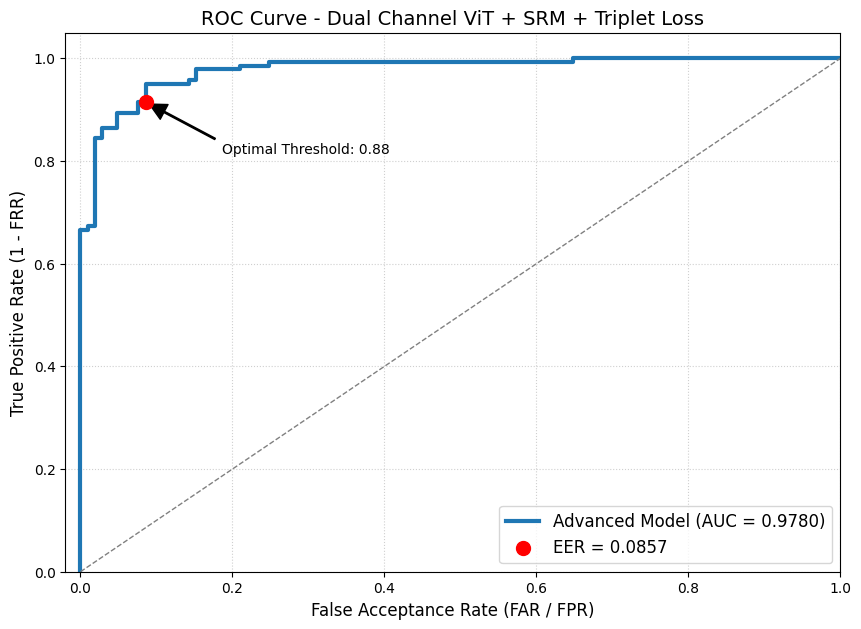

AUC: 0.9780
EER: 0.0857
Threshold at EER: 0.8755


In [51]:
roc, eer = plot_roc(labels, best_probs)

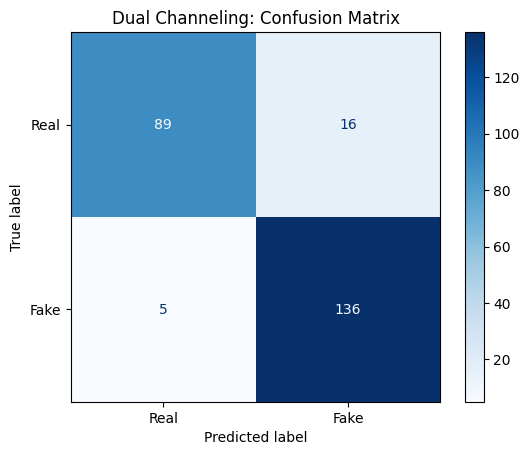

Correctly classified Real (TN): 89
Correctly classified Fake (TP): 136
Real predicted as Fake (FP/FRR errors): 16
Fake predicted as Real (FN/FAR errors): 5


In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
best_preds = (best_probs > 0.5).astype(int)
cm = confusion_matrix(labels, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
disp.plot(cmap='Blues')
plt.title('Dual Channeling: Confusion Matrix')
plt.show()

# show fpr, fnr, tnr, tpr.
tn, fp, fn, tp = cm.ravel()
print(f"Correctly classified Real (TN): {tn}")
print(f"Correctly classified Fake (TP): {tp}")
print(f"Real predicted as Fake (FP/FRR errors): {fp}")
print(f"Fake predicted as Real (FN/FAR errors): {fn}")

#Error Analysis

In [37]:

def find_hard_cases(y_true, y_probs, top_n=3):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    fa_indices = np.where((y_true == 1) & (y_probs < 0.5))[0]

    # Sort by probability in ascending order to find the hard cases
    fa_sorted = fa_indices[np.argsort(y_probs[fa_indices])]
    top_fa = fa_sorted[:top_n]

    fr_indices = np.where((y_true == 0) & (y_probs >= 0.5))[0]
    fr_sorted = fr_indices[np.argsort(y_probs[fr_indices])[::-1]]
    top_fr = fr_sorted[:top_n]

    print(" False Acceptance (Classified Fake as Real)")
    for idx in top_fa:
        print(f"Index: {idx},  True Label: Fake (1),  Predicted Prob: {y_probs[idx]:.4f} ")

    print("False Rejection (Classified Real as Fake) ")
    for idx in top_fr:
        print(f"Index: {idx}, True Label: Real (0) Predicted Prob: {y_probs[idx]:.4f}")

    return top_fa, top_fr

# Assuming best_labels and best_probs were saved from your validation run
top_fa_idx, top_fr_idx = find_hard_cases(labels, best_probs, top_n=3)

 False Acceptance (Classified Fake as Real)
Index: 60,  True Label: Fake (1),  Predicted Prob: 0.0179 
Index: 58,  True Label: Fake (1),  Predicted Prob: 0.2402 
Index: 179,  True Label: Fake (1),  Predicted Prob: 0.3091 
False Rejection (Classified Real as Fake) 
Index: 173, True Label: Real (0) Predicted Prob: 0.9887
Index: 195, True Label: Real (0) Predicted Prob: 0.9885
Index: 125, True Label: Real (0) Predicted Prob: 0.9557


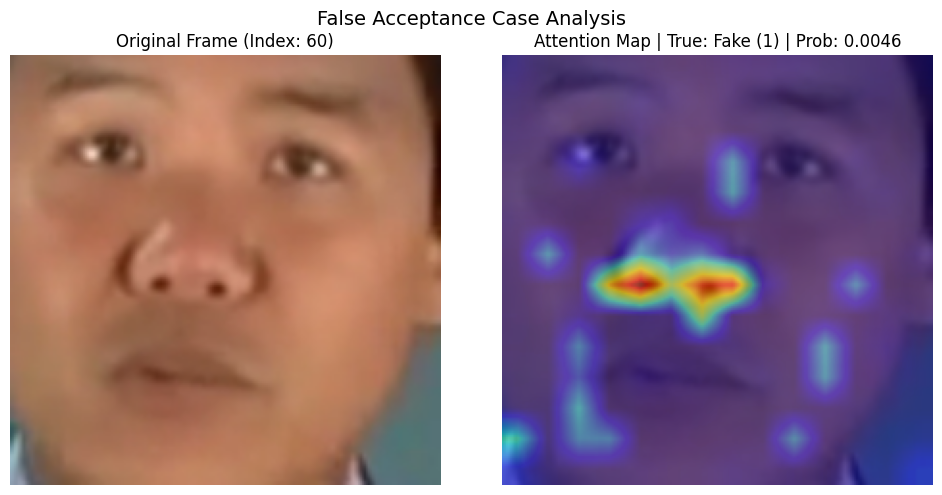

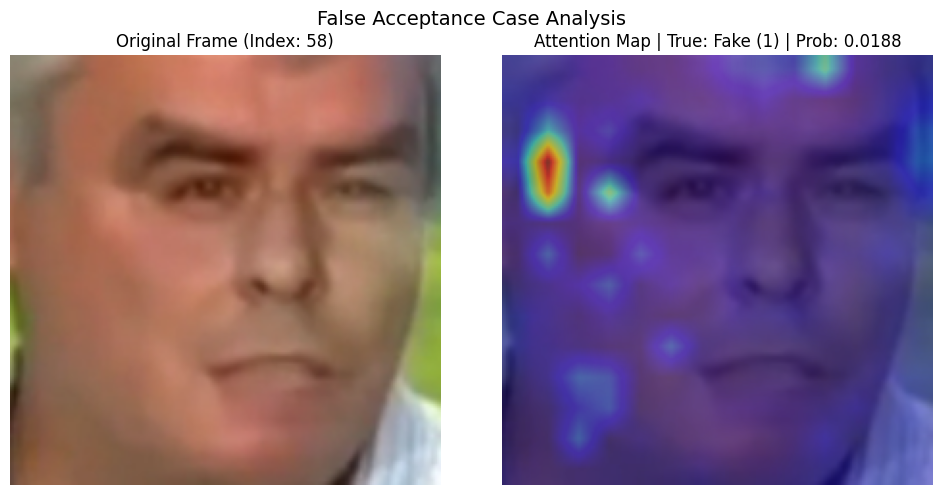

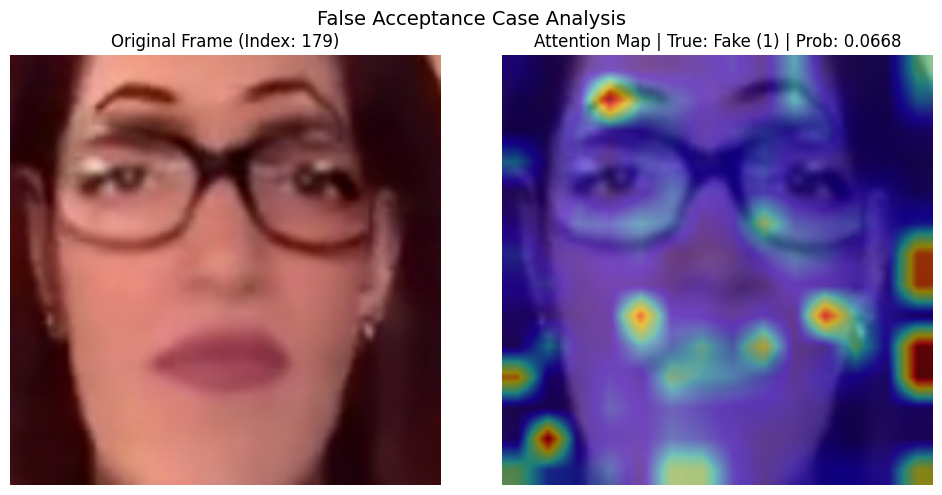

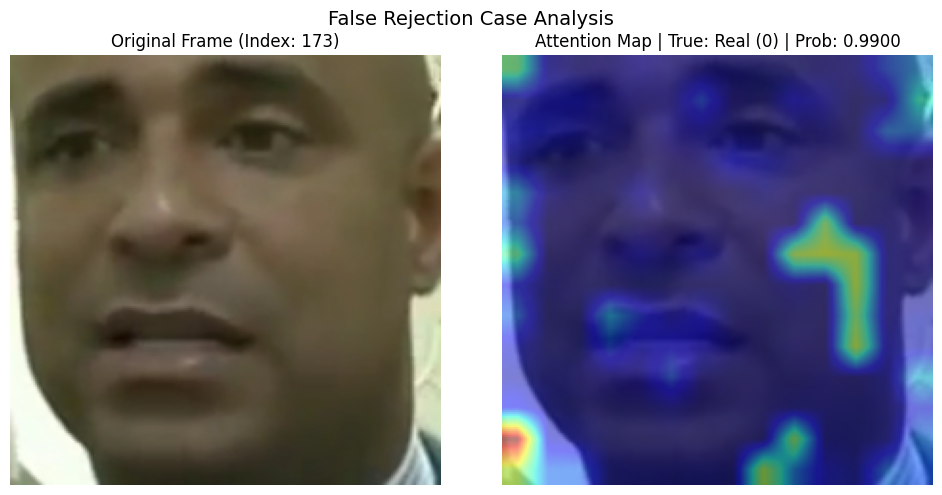

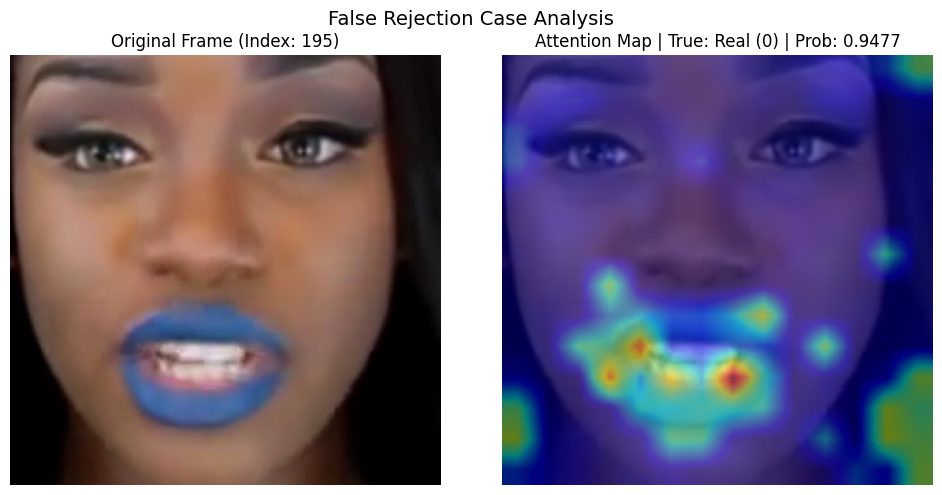

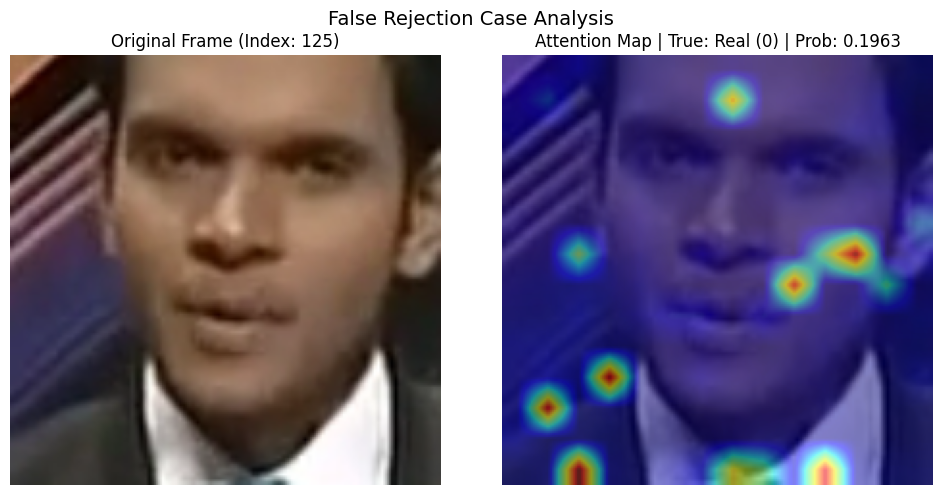

In [38]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

def generate_visual_evidence(model, dataset, indices, device, error_type="Error"):
    model.eval()

    for idx in indices:
        video, label = dataset[idx]
        frame = video[len(video)//2].unsqueeze(0).to(device)

        with torch.no_grad():
            # Get the predicted value
            logits, _, _ = model(video.unsqueeze(0).to(device))
            prob = torch.sigmoid(logits).item()

            # Enable attention outputs for the ViT model
            model.vit.config._attn_implementation = "eager"
            model.vit.config.output_attentions = True

            outputs = model.vit(pixel_values=frame, output_attentions=True, return_dict=True)
            last_attn = outputs.attentions[-1]

        # Calculate heatmap
        mask = last_attn[0, :, 0, 1:].mean(dim=0).reshape(14, 14).detach().cpu().numpy()
        mask = cv2.resize(mask, (224, 224))
        mask = (mask - mask.min()) / (mask.max() - mask.min())

        img = frame.squeeze().permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.5, 0.5, 0.5])
        std = np.array([0.5, 0.5, 0.5])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        # Plot and display the images
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Left plot: original frame
        axes[0].imshow(img)
        axes[0].set_title(f"Original Frame (Index: {idx})")
        axes[0].axis('off')

        # Right plot: Evidence with overlaid heatmap
        axes[1].imshow(img)
        axes[1].imshow(mask, cmap='jet', alpha=0.5)

        true_label_str = "Fake (1)" if label.item() == 1 else "Real (0)"
        axes[1].set_title(f"Attention Map | True: {true_label_str} | Prob: {prob:.4f}")
        axes[1].axis('off')

        plt.suptitle(f"{error_type} Case Analysis", fontsize=14)
        plt.tight_layout()
        plt.show()

generate_visual_evidence(model, val_dataset, top_fa_idx, device, error_type="False Acceptance")

generate_visual_evidence(model, val_dataset, top_fr_idx, device, error_type="False Rejection")

# Cross Dataset Evaluation

In [ ]:
run_batch_processing(cross_data_real,"real",0,cross_data_save_dir)
run_batch_processing(cross_data_fake,"fake",1,cross_data_save_dir)

In [39]:
Cross_X, Cross_y = load_processed_data(cross_data_save_dir)

Data loading complete!
Total Features (X) shape: (203, 16, 224, 224, 3)
Total Labels (y) shape: (203,)


/tmp/ipykernel_1689/1310947257.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette=['#3498db', '#e74c3c'])


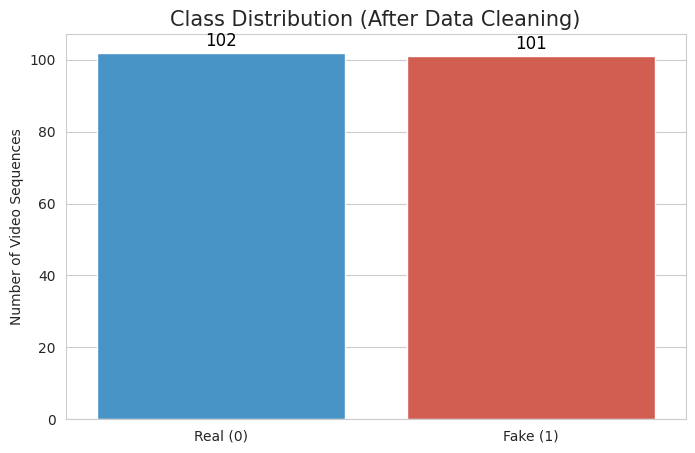

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

counts = pd.Series(Cross_y).value_counts().sort_index()
labels = ['Real (0)', 'Fake (1)']

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = sns.barplot(x=labels, y=counts.values, palette=['#3498db', '#e74c3c'])

# using histograms to shows the distribution after data cleaning
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title("Class Distribution (After Data Cleaning)", fontsize=15)
plt.ylabel("Number of Video Sequences")
plt.show()

In [40]:
# split the data into training and validation


val_dataset = DeepfakeVideoDataset(Cross_X, Cross_y, train = False)


cross_loader = DataLoader(val_dataset,
                        batch_size=32,
                        shuffle=False,
                        num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.load_state_dict(torch.load("best_dual_channel_model.pth", map_location=device))


criterion = nn.BCEWithLogitsLoss()

epoch_loss, cross_acc, cross_f1, y_true, y_probs = evaluate(model, cross_loader, criterion, device)

print(f"ACC: {cross_acc:.4f} | F1: {cross_f1:.4f}")

Using device: cuda
ACC: 0.8128 | F1: 0.8021


AUC : 0.9047
EER : 0.1667
FAR : 0.1373  (Real classified as Fake)
FRR : 0.2376  (Fake classified as Real)
ACC : 0.8128
F1  : 0.8021


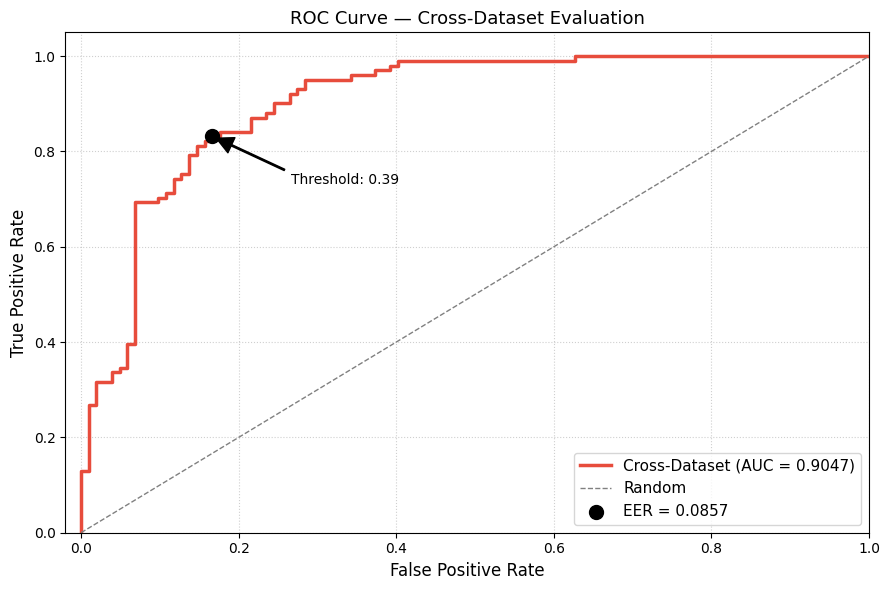

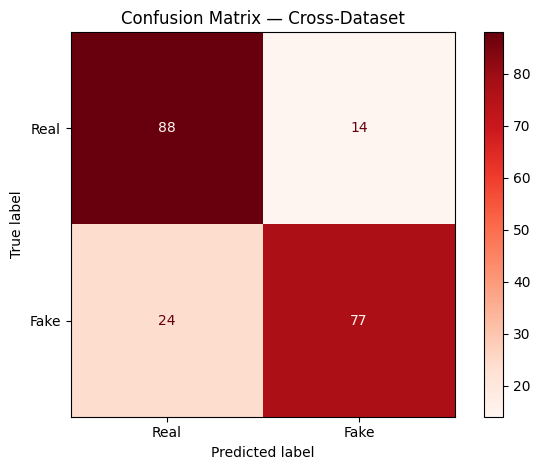

TP (Fake→Fake): 77  |  TN (Real→Real): 88
FP (Real→Fake): 14  |  FN (Fake→Real): 24


In [47]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# AUC / EER / FAR / FRR
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
cross_auc = auc(fpr, tpr)

fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
cross_eer = fpr[eer_idx]
cross_far = np.sum((y_probs > 0.5) & (y_true == 0)) / np.sum(y_true == 0)
cross_frr = np.sum((y_probs <= 0.5) & (y_true == 1)) / np.sum(y_true == 1)

print(f"AUC : {cross_roc:.4f}")
print(f"EER : {cross_eer:.4f}")
print(f"FAR : {cross_far:.4f}  (Real classified as Fake)")
print(f"FRR : {cross_frr:.4f}  (Fake classified as Real)")
print(f"ACC : {cross_acc:.4f}")
print(f"F1  : {cross_f1:.4f}")

# ROC Curve
plt.figure(figsize=(9, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2.5,
         label=f'Cross-Dataset (AUC = {cross_roc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
plt.scatter(fpr[eer_idx], tpr[eer_idx], color='black', s=100, zorder=5,
            label=f'EER = {eer:.4f}')
plt.annotate(f'Threshold: {thresholds[eer_idx]:.2f}',
             xy=(fpr[eer_idx], tpr[eer_idx]),
             xytext=(fpr[eer_idx] + 0.1, tpr[eer_idx] - 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Cross-Dataset Evaluation', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Confusion Matrix
y_preds = (y_probs > 0.5).astype(int)
cm = confusion_matrix(y_true, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
disp.plot(cmap='Reds')
plt.title('Confusion Matrix — Cross-Dataset')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP (Fake→Fake): {tp}  |  TN (Real→Real): {tn}")
print(f"FP (Real→Fake): {fp}  |  FN (Fake→Real): {fn}")

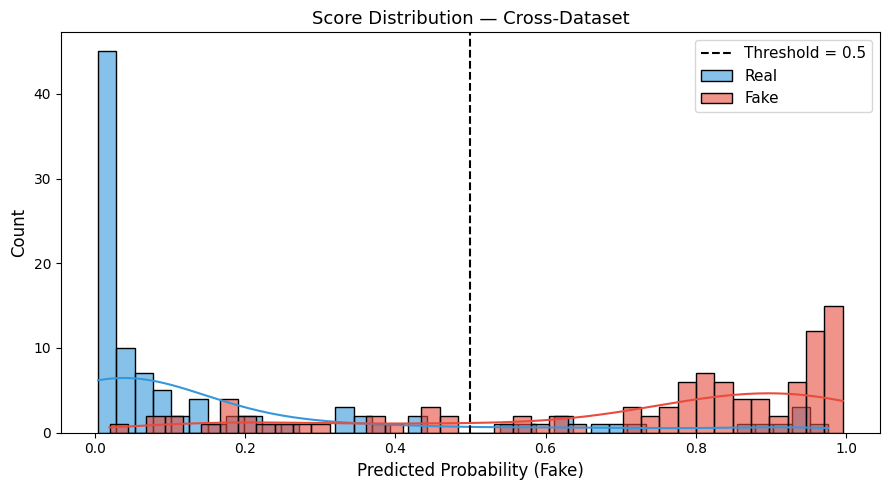

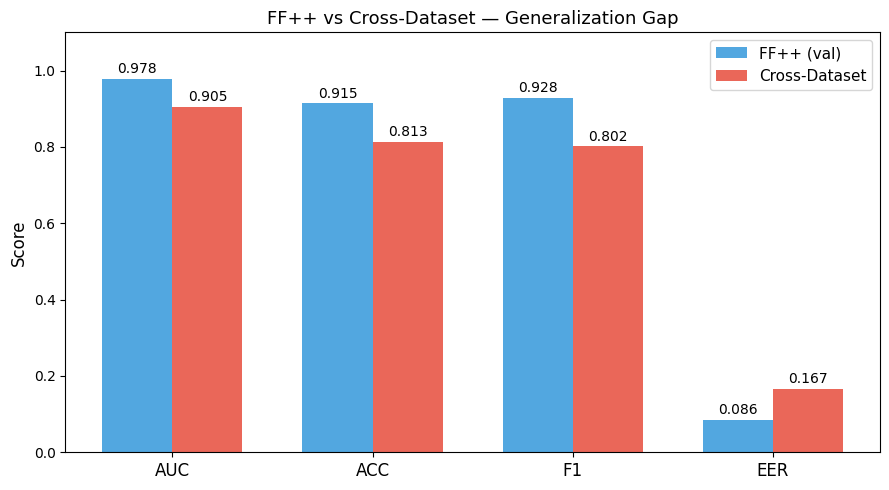

In [52]:

#Score Distribution (Real vs Fake)
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.histplot(y_probs[y_true == 0], bins=40, color='#3498db',
             label='Real', kde=True, alpha=0.6)
sns.histplot(y_probs[y_true == 1], bins=40, color='#e74c3c',
             label='Fake', kde=True, alpha=0.6)
plt.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold = 0.5')
plt.xlabel('Predicted Probability (Fake)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Score Distribution — Cross-Dataset', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

#FF++ vs Cross-Dataset compare data
metrics = ['AUC', 'ACC', 'F1', 'EER']
ff_scores    = [roc, acc, best_val_f1, eer]
cross_scores = [cross_auc, cross_acc, cross_f1, cross_eer]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, ff_scores,    width, label='FF++ (val)',     color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, cross_scores, width, label='Cross-Dataset',  color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('FF++ vs Cross-Dataset — Generalization Gap', fontsize=13)
ax.legend(fontsize=11)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.show()